# SI Figure S1: Strategy Comparison

Single panel: best adsorption energy across 4 strategies on CMU20.
- AdsMind Full
- Random (n=20)
- Heuristic
- Adsorb-Agent


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('default')
sns.set_theme(style='ticks', context='paper', font_scale=1.2)
okabe = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
         '#0072B2', '#D55E00', '#CC79A7', '#000000']
BASE = Path('../../..')
print('Libraries loaded')


Libraries loaded


In [2]:
# === Load Panel a: Strategy Comparison ===

data = []

# AdsMind Full (GPT)
df = pd.read_csv(BASE / 'research/results/processed/si_figures/basic_experiments/cmu20/gpt/full/summary.csv')
for _, r in df.iterrows():
    data.append({'case': int(r['case_id']), 'method': 'AdsMind Full', 'energy': float(r['best_energy'])})

# Random (n=20)
df = pd.read_csv(BASE / 'research/results/processed/si_figures/basic_experiments/cmu20/baselines/random_n20/summary.csv')
for _, r in df.iterrows():
    data.append({'case': int(r['case_id']), 'method': 'Random (n=20)', 'energy': float(r['best_energy'])})

# Heuristic
df = pd.read_csv(BASE / 'research/results/processed/si_figures/basic_experiments/cmu20/baselines/heuristic/summary.csv')
for _, r in df.iterrows():
    data.append({'case': int(r['case_id']), 'method': 'Heuristic', 'energy': float(r['best_energy'])})

# Adsorb-Agent
df = pd.read_csv(BASE / 'research/results/processed/si_figures/basic_experiments/cmu20/baselines/adsorbagent_mace_mp0_small_gpt54/summary.csv')
for _, r in df.iterrows():
    if pd.notna(r['best_adsorption_energy_eV']):
        data.append({'case': int(r['case_id']), 'method': 'Adsorb-Agent', 'energy': float(r['best_adsorption_energy_eV'])})

df_a = pd.DataFrame(data)
methods = df_a.groupby('method')['energy'].mean().sort_values().index.tolist()
print(f'{len(df_a)} records, {len(methods)} methods')


76 records, 4 methods


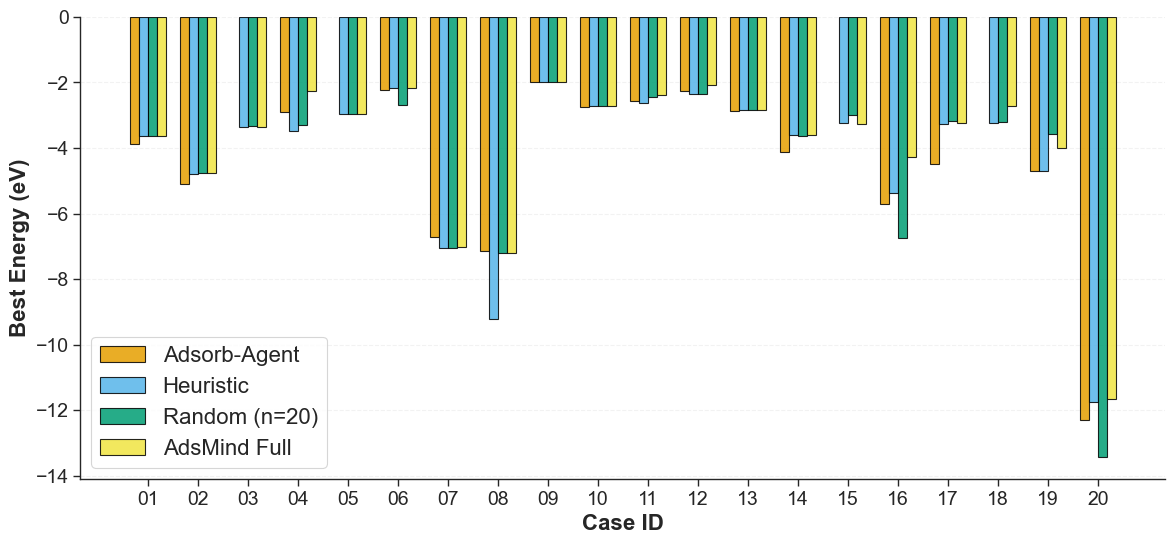

Saved: ./si_figure_S1_single.png


In [3]:
# ============================================================
# SI FIGURE S1: Strategy Comparison Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

cases = np.arange(1, 21)
n_m = len(methods)
bar_w = 0.18
for i, method in enumerate(methods):
    sub = df_a[df_a['method'] == method].sort_values('case')
    x = sub['case'].values.astype(float) + i * bar_w - n_m * bar_w / 2 + bar_w / 2
    ax.bar(x, sub['energy'], width=bar_w, label=method,
           color=okabe[i % 8], alpha=0.85, edgecolor='black')

ax.set_xlabel('Case ID', fontsize=16, fontweight='bold')
ax.set_ylabel('Best Energy (eV)', fontsize=16, fontweight='bold')
ax.set_xticks(cases)
ax.set_xticklabels([f'{i:02d}' for i in cases], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(frameon=True, fontsize=16, loc='lower left')
ax.grid(True, alpha=0.25, linestyle='--', axis='y')
sns.despine()

# Save
plt.savefig('./si_figure_S1_single.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ./si_figure_S1_single.png')